<a href="https://colab.research.google.com/github/MithravindaU/FraudShield-AI-/blob/main/Mlfrauddetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ml/creditcard.csv"

df = pd.read_csv(file_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
import os

os.chdir("/content/drive/MyDrive/ml")

print(os.getcwd())

/content/drive/MyDrive/ml


In [ ]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df['Class'].value_counts())

print(df['Class'].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
print("Duplicate Rows")

print(df.duplicated().sum())

Duplicate Rows
1081


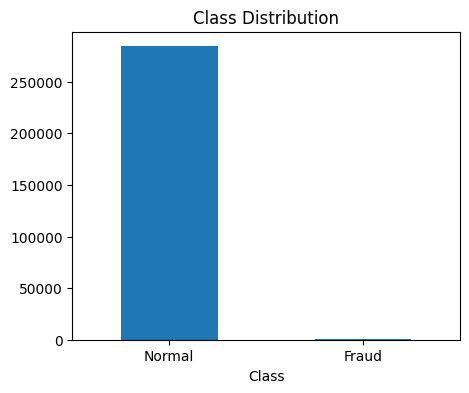

In [ ]:
plt.figure(figsize=(5,4))

df['Class'].value_counts().plot(kind='bar')

plt.xticks([0,1],["Normal","Fraud"],rotation=0)

plt.title("Class Distribution")

plt.show()

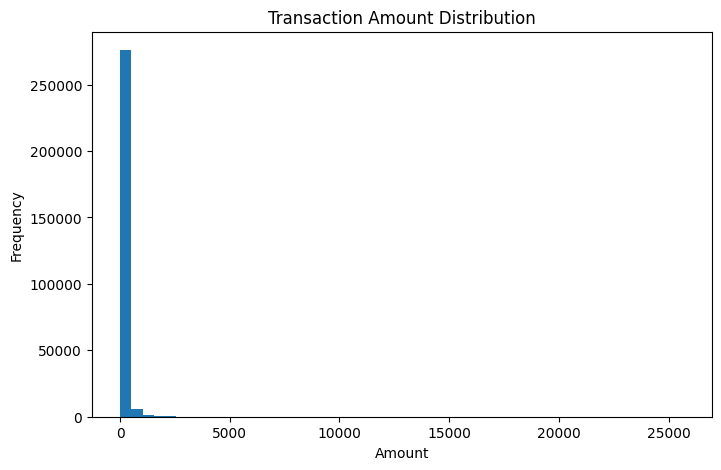

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Amount'],bins=50)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

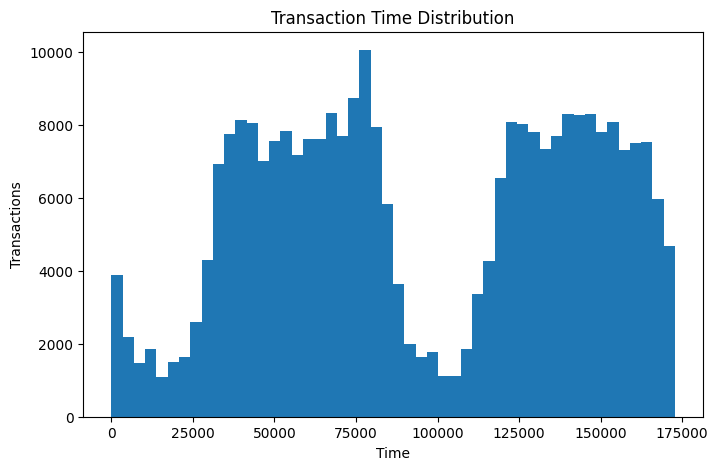

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Time'],bins=50)

plt.title("Transaction Time Distribution")

plt.xlabel("Time")

plt.ylabel("Transactions")

plt.show()

In [ ]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

df['Time'] = scaler.fit_transform(df[['Time']])

In [ ]:
X = df.drop("Class",axis=1)

y = df["Class"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

prob = rf.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test,pred))

print(confusion_matrix(y_test,pred))

print("ROC AUC Score:",roc_auc_score(y_test,prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   18    80]]
ROC AUC Score: 0.9630272515590367


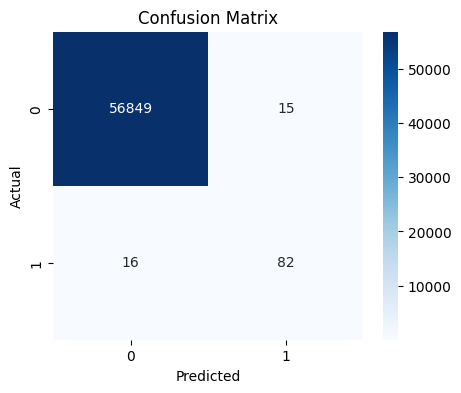

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test,pred_smote)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

print(y_train.value_counts())

print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote,y_train_smote)

pred_smote = rf_smote.predict(X_test)

prob_smote = rf_smote.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test,pred_smote))

print(confusion_matrix(y_test,pred_smote))

print("ROC AUC:",roc_auc_score(y_test,prob_smote))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56849    15]
 [   16    82]]
ROC AUC: 0.973103297664029


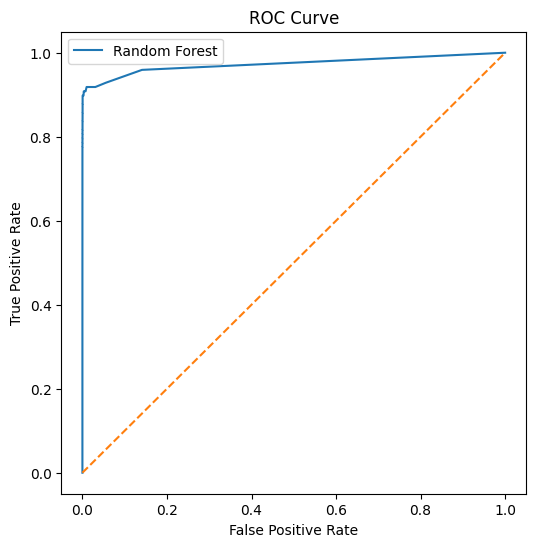

In [ ]:
fpr,tpr,_=roc_curve(y_test,prob_smote)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest + SMOTE"],
    "ROC-AUC": [
        roc_auc_score(y_test, prob),
        roc_auc_score(y_test, prob_smote)
    ]
})

comparison

,Model,ROC-AUC
0,Random Forest,0.963027
1,Random Forest + SMOTE,0.973103


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Without SMOTE": [
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ],
    "With SMOTE": [
        precision_score(y_test, pred_smote),
        recall_score(y_test, pred_smote),
        f1_score(y_test, pred_smote),
        roc_auc_score(y_test, prob_smote)
    ]
})

comparison

,Metric,Without SMOTE,With SMOTE
0,Precision,0.941176,0.845361
1,Recall,0.816327,0.836735
2,F1-Score,0.874317,0.841026
3,ROC-AUC,0.963027,0.973103


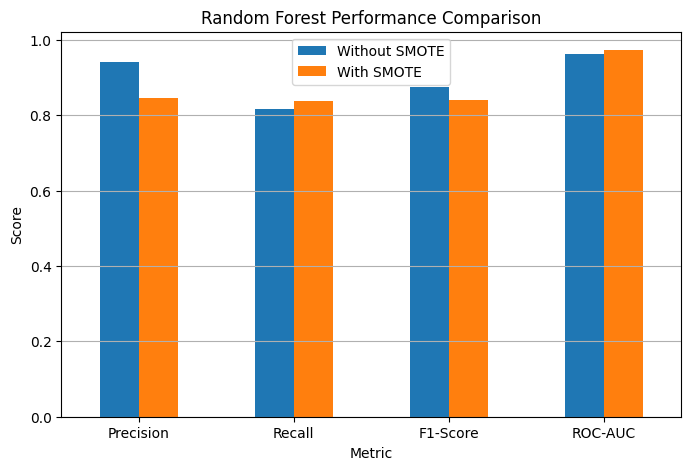

In [ ]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Random Forest Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

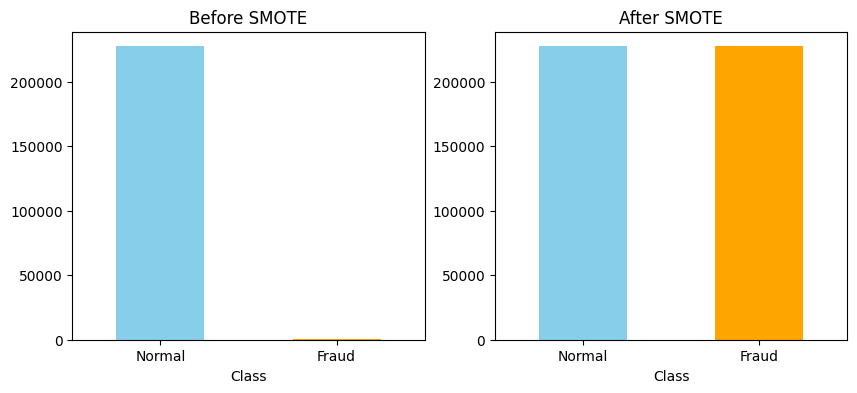

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

y_train.value_counts().plot(
    kind="bar",
    ax=ax[0],
    color=["skyblue","orange"]
)

ax[0].set_title("Before SMOTE")
ax[0].set_xticklabels(["Normal","Fraud"],rotation=0)

y_train_smote.value_counts().plot(
    kind="bar",
    ax=ax[1],
    color=["skyblue","orange"]
)

ax[1].set_title("After SMOTE")
ax[1].set_xticklabels(["Normal","Fraud"],rotation=0)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_smote.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.195607
10,V10,0.110459
4,V4,0.106133
12,V12,0.095085
17,V17,0.085002
3,V3,0.060455
11,V11,0.056356
16,V16,0.043757
2,V2,0.036986
9,V9,0.026203


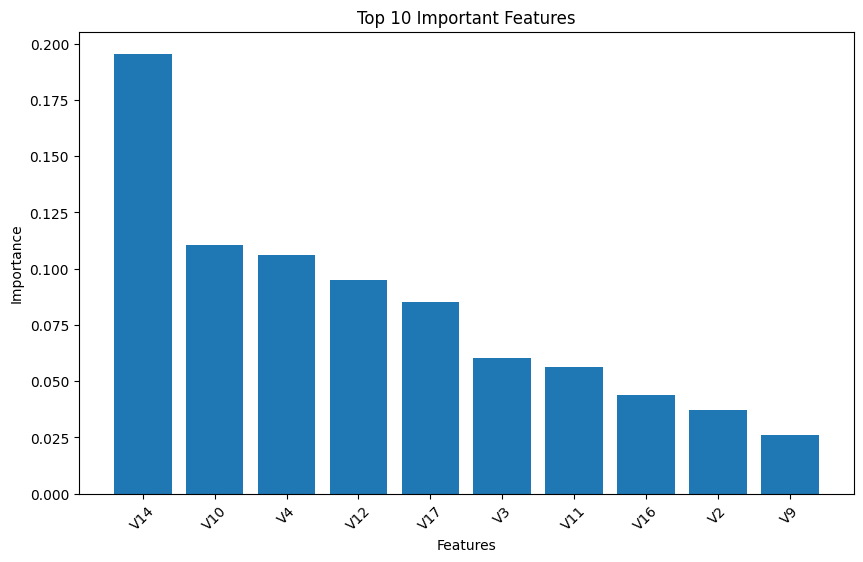

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"].head(10),
    importance["Importance"].head(10)
)

plt.xticks(rotation=45)

plt.title("Top 10 Important Features")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()